In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/noordeen/insurance-premium-prediction/insurance.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("/kaggle/input/datasets/noordeen/insurance-premium-prediction/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


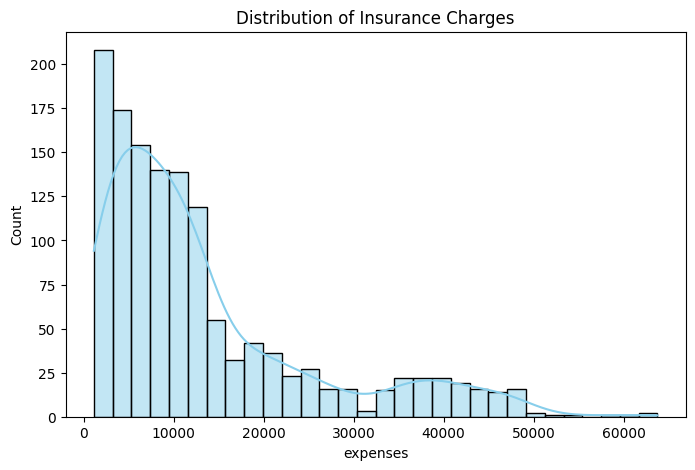

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['expenses'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Insurance Charges")
plt.xlabel("expenses")
plt.show()

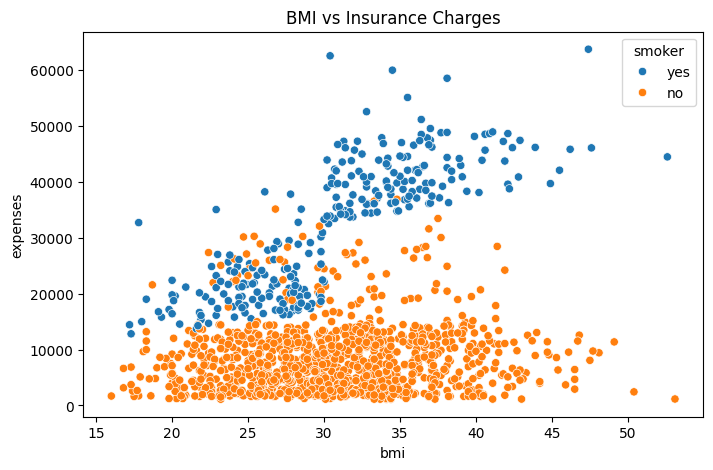

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='bmi', y='expenses', hue='smoker')
plt.title("BMI vs Insurance Charges")
plt.show()

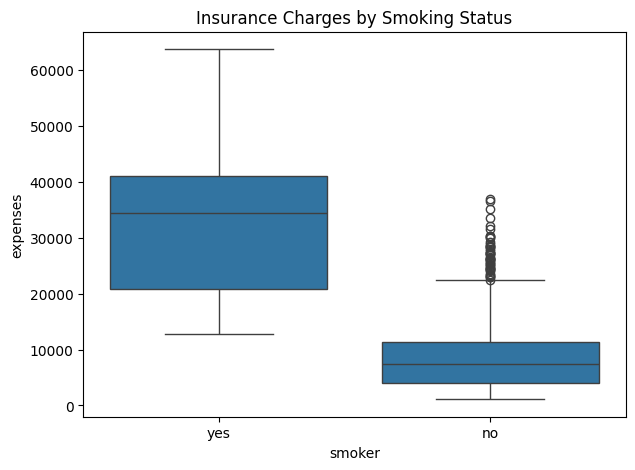

In [9]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='smoker', y='expenses')
plt.title("Insurance Charges by Smoking Status")
plt.show()

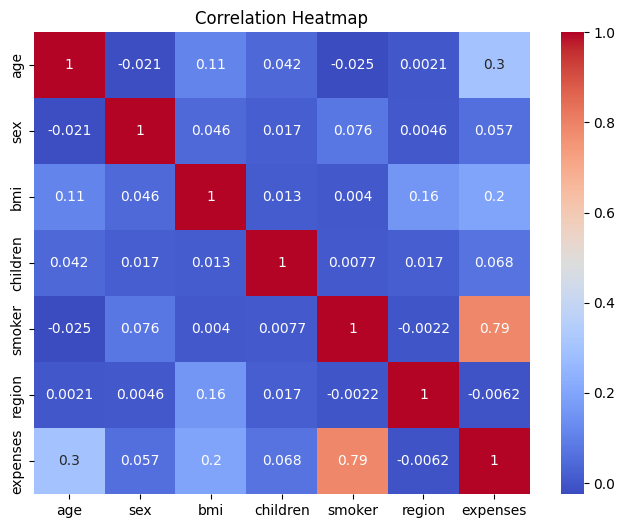

In [10]:
temp = df.copy()

le = LabelEncoder()

for col in ['sex','smoker','region']:
    temp[col] = le.fit_transform(temp[col])

plt.figure(figsize=(8,6))
sns.heatmap(temp.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
df = df.drop_duplicates()

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
X = df.drop("expenses", axis=1)
y = df["expenses"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [19]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

pred_ridge = ridge.predict(X_test_scaled)

In [20]:
lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)

pred_lasso = lasso.predict(X_test_scaled)

In [21]:
def evaluate(y_true, pred):

    mae = mean_absolute_error(y_true, pred)

    mse = mean_squared_error(y_true, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, pred)

    return [mae, mse, rmse, r2]

In [22]:
results = pd.DataFrame({

'Model':['Linear Regression','Ridge Regression','Lasso Regression'],

'MAE':[
evaluate(y_test,pred_lr)[0],
evaluate(y_test,pred_ridge)[0],
evaluate(y_test,pred_lasso)[0]
],

'MSE':[
evaluate(y_test,pred_lr)[1],
evaluate(y_test,pred_ridge)[1],
evaluate(y_test,pred_lasso)[1]
],

'RMSE':[
evaluate(y_test,pred_lr)[2],
evaluate(y_test,pred_ridge)[2],
evaluate(y_test,pred_lasso)[2]
],

'R2 Score':[
evaluate(y_test,pred_lr)[3],
evaluate(y_test,pred_ridge)[3],
evaluate(y_test,pred_lasso)[3]
]

})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4177.267596,3.548147e+07,5956.632572,0.806910
1,Ridge Regression,4179.843668,3.551590e+07,5959.522021,0.806723
2,Lasso Regression,4177.435834,3.548880e+07,5957.247633,0.806870


##Conclusion

The Linear Regression, Ridge Regression, and Lasso Regression models all performed similarly on the insurance premium dataset. Linear Regression achieved the highest R² score with the lowest prediction error, indicating the best overall fit for this dataset. Ridge Regression reduced the magnitude of the coefficients, helping control overfitting, while Lasso Regression further penalized less important features by shrinking some coefficients to zero. Since the dataset is relatively small with limited multicollinearity, regularization did not significantly improve predictive performance, though it produced simpler and more stable models.